In [7]:
import numpy as np
import pandas as pd
df = pd.read_csv('tech_layoffs_2026_tracker.csv')
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score,classification_report
from sklearn.tree import DecisionTreeClassifier,plot_tree

In [2]:
df.head()

,company,layoff_date,jobs_cut,pct_workforce_cut,sector,country,hq_city,ai_cited,reason_stated,company_revenue_2025_bn,...,layoffs_2024,layoffs_2025,verified_source,month,quarter,region,layoff_size_category,stock_reaction,laid_off_vs_headcount_pct,data_as_of
0,Amazon,2026-01-15,16000,2.7,E-Commerce/Cloud,USA,Seattle,False,Reduce bureaucracy and management layers,716.9,...,4000,14000,CNBC / NetworkWorld,January 2026,Q1 2026,North America,Mega (5K+),Positive,1.03,"March 18, 2026"
1,Block,2026-02-28,4000,40.0,Fintech,USA,San Francisco,True,AI tools replace roles enabling smaller teams,22.4,...,0,1000,CNBC / Crunchbase,February 2026,Q1 2026,North America,Large (2K-5K),Positive,40.00,"March 18, 2026"
2,Meta Reality Labs,2026-01-20,1500,10.0,Social Media/VR,USA,Menlo Park,True,Pivot from metaverse to AI research,164.5,...,0,500,InformationWeek / NYT,January 2026,Q1 2026,North America,Medium (500-2K),Positive,1.90,"March 18, 2026"
3,Atlassian,2026-03-14,1600,10.0,Enterprise Software,Australia,Sydney,True,Pivot to AI-first company strategy,5.1,...,0,500,TechRepublic / Metaintro,March 2026,Q1 2026,Asia-Pacific,Medium (500-2K),Positive,10.00,"March 18, 2026"
4,Oracle,2026-02-01,30000,15.0,Enterprise Software,USA,Austin,True,AI data centres replace human ops,52.9,...,6000,10000,IBTimes,February 2026,Q1 2026,North America,Mega (5K+),Positive,15.00,"March 18, 2026"


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28 entries, 0 to 27
Data columns (total 26 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   company                        28 non-null     object 
 1   layoff_date                    28 non-null     object 
 2   jobs_cut                       28 non-null     int64  
 3   pct_workforce_cut              28 non-null     float64
 4   sector                         28 non-null     object 
 5   country                        28 non-null     object 
 6   hq_city                        28 non-null     object 
 7   ai_cited                       28 non-null     bool   
 8   reason_stated                  28 non-null     object 
 9   company_revenue_2025_bn        28 non-null     float64
 10  pre_layoff_headcount           28 non-null     int64  
 11  stock_change_day_pct           28 non-null     float64
 12  simultaneous_ai_investment_bn  28 non-null     float

In [6]:
df.describe()

,jobs_cut,pct_workforce_cut,company_revenue_2025_bn,pre_layoff_headcount,stock_change_day_pct,simultaneous_ai_investment_bn,layoffs_2024,layoffs_2025,laid_off_vs_headcount_pct
count,28.000000,28.000000,28.00000,2.800000e+01,28.000000,28.000000,28.000000,28.000000,28.000000
mean,3612.357143,10.639286,63.62500,1.076631e+05,0.832143,14.046429,944.642857,1951.785714,10.452143
std,6546.591373,10.433505,139.44986,2.915339e+05,1.742721,34.751824,1615.511574,3328.482085,10.719330
min,50.000000,0.100000,0.00000,2.500000e+03,-2.100000,0.000000,0.000000,0.000000,0.320000
25%,989.500000,2.525000,3.50000,8.750000e+03,-0.325000,0.000000,0.000000,0.000000,1.975000
50%,1000.000000,7.750000,9.40000,1.850000e+04,0.650000,0.450000,0.000000,500.000000,7.205000
75%,2050.000000,15.000000,53.90000,8.050000e+04,1.850000,2.250000,1125.000000,1812.500000,15.810000
max,30000.000000,40.000000,716.90000,1.550000e+06,5.800000,115.000000,6000.000000,14000.000000,40.000000


In [8]:
df['layoff_date'] = pd.to_datetime(df['layoff_date'])
df = df.drop(['company','ceo_quote','verified_source','data_as_of'],axis=1)

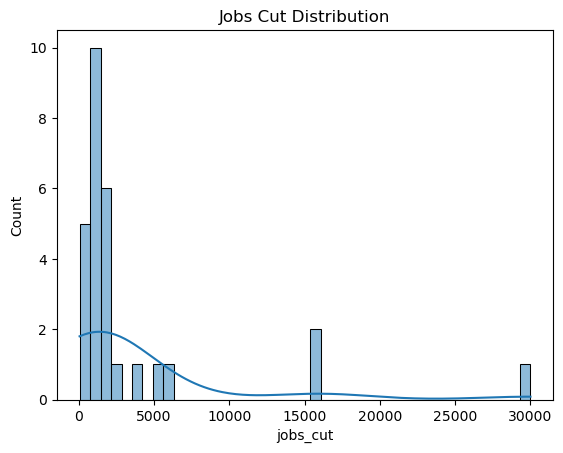

In [9]:
sns.histplot(df['jobs_cut'],kde=True)
plt.title("Jobs Cut Distribution")
plt.show()

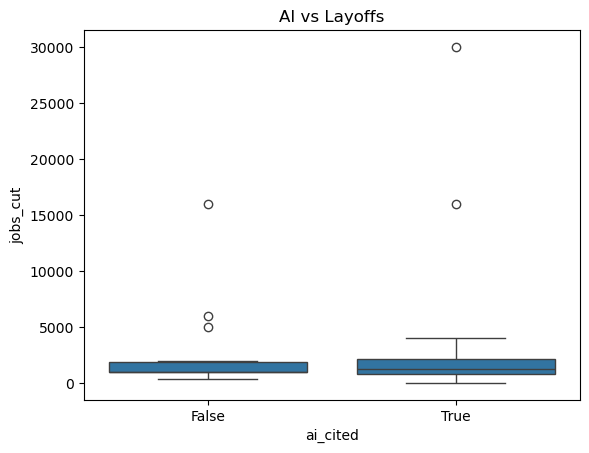

In [10]:
sns.boxplot(x='ai_cited',y='jobs_cut',data=df)
plt.title("AI vs Layoffs")
plt.show()

In [12]:
X = df.drop('stock_reaction',axis=1)
y = df['stock_reaction']

In [13]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [15]:
df['layoff_date'] = pd.to_datetime(df['layoff_date'])
df['year'] = df['layoff_date'].dt.year
df['month_num'] = df['layoff_date'].dt.month
df['day'] = df['layoff_date'].dt.day
df = df.drop('layoff_date', axis=1)

In [17]:
print(df.dtypes)

jobs_cut                           int64
pct_workforce_cut                float64
sector                             int32
country                            int32
hq_city                            int32
ai_cited                            bool
reason_stated                      int32
company_revenue_2025_bn          float64
pre_layoff_headcount               int64
stock_change_day_pct             float64
simultaneous_ai_investment_bn    float64
roles_most_affected                int32
replacement_roles                  int32
layoffs_2024                       int64
layoffs_2025                       int64
month                              int32
quarter                            int32
region                             int32
layoff_size_category               int32
stock_reaction                     int32
laid_off_vs_headcount_pct        float64
year                               int32
month_num                          int32
day                                int32
dtype: object


In [24]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])

In [25]:
X = df.drop('stock_reaction', axis=1)
y = df['stock_reaction']
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2)
from sklearn.tree import DecisionTreeClassifier
model = DecisionTreeClassifier(max_depth=3)
model.fit(X_train,y_train)   

DecisionTreeClassifier(max_depth=3)

In [26]:
y_pred = model.predict(X_test)

In [27]:
print("Accuracy:",accuracy_score(y_test,y_pred))
print(classification_report(y_test,y_pred))

Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         2
           1       1.00      1.00      1.00         1
           2       1.00      1.00      1.00         3

    accuracy                           1.00         6
   macro avg       1.00      1.00      1.00         6
weighted avg       1.00      1.00      1.00         6



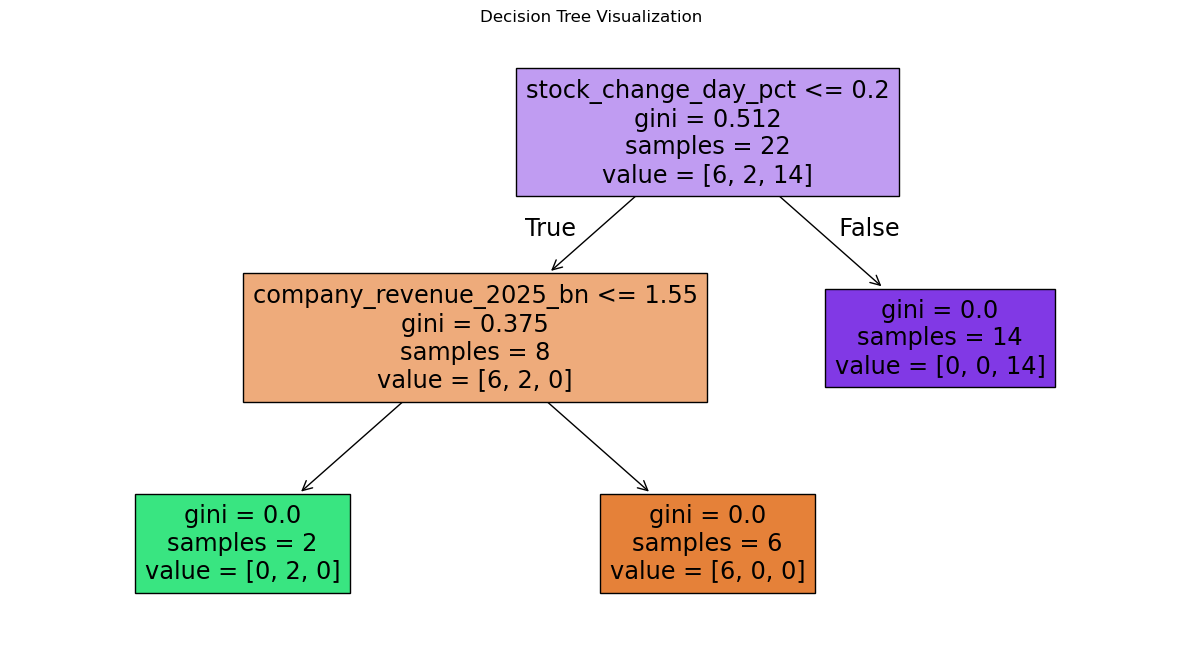

In [28]:
plt.figure(figsize=(15,8))
plot_tree(model,feature_names=X.columns,filled=True)
plt.title("Decision Tree Visualization")
plt.show()

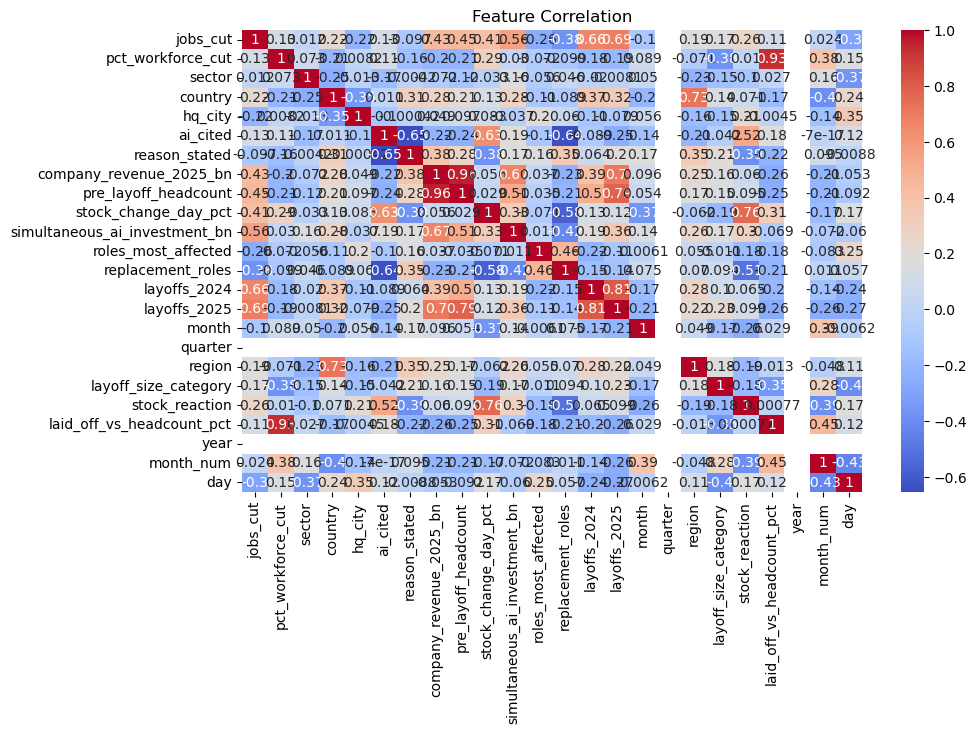

In [29]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(),annot=True,cmap='coolwarm')
plt.title("Feature Correlation")
plt.show()